# Third Notebook

This notebook escalates in complexity.

This activity will use python to perform variable selection in a dataset and estimate a simple Nowcasting model based on OLS. We will:

- Load a full data
- Estimate LARS and compare it with OLS
- Nowcast GDP with OLS and several information sets

Files should be saved in ```notebook_3_files``` folder.

*Make sure the folder is in the same directory as this notebook.*

This Notebook has **parts** of the code you need to to the tasks above. Follow the notes to complete or write the pieces of code you may need to finish.



## Load Libraries

First, we load and verify that libraries load correctly. Otherwise, install via conda or pip

You may have to install any of the following:

```conda install sklearn --yes```

```conda install matplotlib --yes```

```conda install statsmodels --yes```

In [287]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from copy import deepcopy
from sklearn.linear_model import Lars

scaler = StandardScaler()

# Load the data

Read and clean (seasonality and stationarity) the data.

In [288]:
data = pd.read_csv('notebook_3_files/data_full.csv', parse_dates=True, index_col='date')
data.head(2)

,XIMP1001,XIMP1002,XIMP1003,XIMP1004,XIMP1005,XIMP1006,XIMP1007,XIMP1008,XIMP1009,XIMP1010,...,UNTL9305,UNTL9306,UNTL9307,UNTL9308,UNTL9309,UNTL9310,UNTL9100,UNTL9101,UNTL9300,UNTL9301
date,,,,,,,,,,,,,,,,,,,,,
2012-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1733.413031,2333.054790,9196.965173,11608.406551,403271.120527,39739.857455,6397.754096,160.855881,115954.087427,1781.034760
2012-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2195.223720,1747.708021,9425.924103,14279.820776,537522.811678,34611.790605,6186.863317,154.792484,148960.086790,1952.801482


**COMPLEX SEASONALITY**

Our dataset has mixed frequencies. This time we will start accounting for mixed frequencies.

We are going to apply seasonality filters based on the data frequency. To do so, load the ```metadata.csv``` --a file that describes all variables in the data.

In [289]:
metadata = pd.read_csv('notebook_3_files/meta_full.csv')
# The column with variable names
meta_col = 'ticket'

metadata

,type,series,name,ticket,freq,unstructured,nominal,block_g,block_s,block_r,block_l,months_lag,agg_method
0,R,gdp,NaN,RGDP0000,q,2,0,1,0,1,0,2,mean
1,M,cpi,NaN,MCPI0000,m,0,0,1,0,0,0,1,mean
2,X,imports_animal_and_vegetable_oils_and_fats,NaN,XIMP1001,q,0,1,1,0,1,0,0,mean
3,X,imports_beverages_and_tobacco,NaN,XIMP1002,q,0,1,1,0,1,0,0,mean
4,X,imports_chemicals,NaN,XIMP1003,q,0,1,1,0,1,0,0,mean
...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,U,ntl3_ports_sumw30,NaN,UNTL3310,m,1,0,1,0,1,0,0,mean
408,U,ntl1_sumw30,NaN,UNTL3100,m,1,0,1,0,1,0,0,mean
409,U,ntl1_meanw30,NaN,UNTL3101,m,1,0,1,0,1,0,0,mean
410,U,ntl3_sumw30,NaN,UNTL3300,m,1,0,1,0,1,0,0,mean


The metadata describes which variables are real vs nominal. Use this information to deflate.

In [290]:
cpi = 'MCPI0000'
base = data[cpi][data.index.year == 2018].mean()
nominal = metadata.loc[metadata['nominal']==1][meta_col].values
for column in data.columns :
    if column in nominal : data[column] = data[column]*data[cpi]/base

Here we address seasonality with different filters depending on whether data is monthly, weekly, daily, or quarterly.

In [291]:
# this loop seasonally-adjusts the variables
quarterly = metadata.loc[metadata['freq']=='q'][meta_col].values
monthly = metadata.loc[metadata['freq']=='m'][meta_col].values
weekly = metadata.loc[metadata['freq']=='w'][meta_col].values
daily = metadata.loc[metadata['freq']=='d'][meta_col].values
for column in data.columns :
    if len(data[column].dropna(how='all', axis=0))>12 :
        if column in quarterly :
            data[column] = seasonal_decompose(data[column].dropna(how='all', axis=0), model='additive', extrapolate_trend='freq', period=4).trend
        elif column in monthly :
            data[column] = seasonal_decompose(data[column].dropna(how='all', axis=0), model='additive', extrapolate_trend='freq', period=12).trend
        elif column in daily :
            data[column] = seasonal_decompose(data[column].dropna(how='all', axis=0), model='additive', extrapolate_trend='freq', period=31).trend


Now take differences:

In [292]:
# this loop calculates growth rates
for column in data.columns :
    if column in quarterly : data[column] = data[column].dropna(how='all', axis=0).pct_change()*100
    else : data[column] = data[column].dropna(how='all', axis=0).pct_change()*100
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(how='all', axis=0, inplace=True)
data.dropna(how='all', axis=1, inplace=True)
data.head(5)

,XIMP1001,XIMP1002,XIMP1003,XIMP1004,XIMP1005,XIMP1006,XIMP1007,XIMP1008,XIMP1009,XIMP1010,...,UNTL9305,UNTL9306,UNTL9307,UNTL9308,UNTL9309,UNTL9310,UNTL9100,UNTL9101,UNTL9300,UNTL9301
date,,,,,,,,,,,,,,,,,,,,,
2012-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.090621,-0.100796,0.052565,1.221647,0.166635,-0.020264,0.154373,-0.520357,0.178252,0.307060
2012-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.090538,-0.100898,0.052537,1.206903,0.166358,-0.020268,0.154135,-0.523079,0.177935,0.306120
2012-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.090457,-0.101000,0.052510,1.192510,0.166082,-0.020272,0.153897,-0.525829,0.177619,0.305186
2012-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.090375,-0.101102,0.052482,1.178457,0.165806,-0.020276,0.153661,-0.528609,0.177304,0.304257
2012-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.090293,-0.101204,0.052455,1.164731,0.165532,-0.020280,0.153425,-0.531418,0.176990,0.303334


An example with Google Trends data:

<Axes: xlabel='date'>

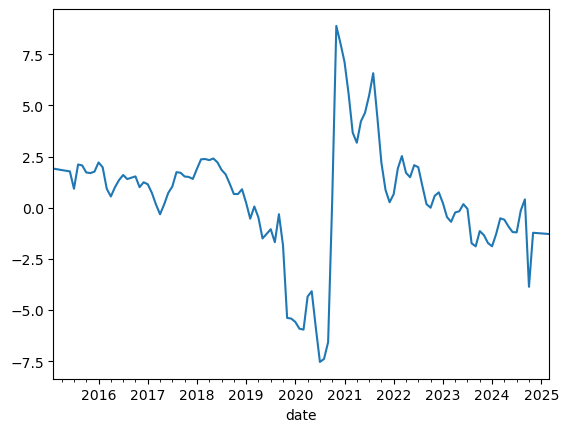

In [293]:
data['UGTR0000'].dropna().plot()

# Variable Selection: LARS

Start by loading the helper functions.

In [294]:
def estimate_factors(X, r_max=10, criterion='IC1'):
    '''
    Information criteria to PCA.
    Bai and Ng (2002)
    inputs:
    - X: df
    - r_max: max number of factors (should be less than T or N)
    - criterion: conservative criteria is IC3
    '''
    
    T, N = X.shape
    r_max = min(r_max, T - 1)  # enforce theoretical max
    IC_vals = []
    
    for r in range(r_max + 1):
        if r == 0:
            sigma2_r = np.mean(X.values ** 2)
        else:
            pca = PCA(n_components=r)
            X_scaled = scaler.fit_transform(X)
            F_hat = pca.fit_transform(X_scaled)
            Lambda_hat = X_scaled.T @ F_hat / T
            X_hat = F_hat @ Lambda_hat.T
            sigma2_r = np.mean((X_scaled - X_hat).values ** 2)
    
        if criterion == 'IC1':
            penalty = r * (N + T) / (N * T) * np.log(N * T / (N + T))
        elif criterion == 'IC2':
            penalty = r * (N + T) / (N * T) * np.log(min(N, T))
        elif criterion == 'IC3':
            penalty = r * np.log(min(N, T)) / min(N, T)
        else:
            raise ValueError("Invalid criterion")
    
        IC_vals.append(np.log(sigma2_r) + penalty)

    return np.argmin(IC_vals)



def lars_variable_ranking(df, target, max_vars=None, test = None , factors = 5 ):
    """
    Stepwise LARS variable selection: rank variables by their entry into the model.
    - df: DataFrame with predictors and target
    - target: name of the target variable
    - max_vars: number of variables to select; if None, continue until all are ranked
    Returns:
    - selected_vars: ordered list of variable names by entry into the LARS model

    Chinn, M. D., Meunier, B., & Stumpner, S. (2023). Nowcasting world trade with machine learning: a three-step approach (No. w31419). National Bureau of Economic Research.
    """
    df0 = deepcopy(df)
    
    selected_order = []
    count = 0
    max_vars = max_vars or (df0.shape[1] - 1)

    while count < max_vars:
        X = df0.drop(columns=[target])
        y = df0[target]

        # Stop if no variables remain
        if X.shape[1] == 0 : break

        # Fit LARS model
        model = Lars(n_nonzero_coefs=X.shape[1], jitter=0 , random_state=0)
        model.fit(X, y)

        # coef_path_ has shape (n_features, n_steps)
        coef_path = np.array(model.coef_path_)
        # Count how many times each variable is zero
        zero_counts = (coef_path == 0).sum(axis=1)

        # Summary table
        out = pd.DataFrame({'Variable': X.columns, 'ZeroCount': zero_counts})
        out = out.sort_values('ZeroCount')
        
        # Take variables that are uniquely at this ZeroCount level
        grouped = out.groupby('ZeroCount')
        selected = grouped.filter(lambda g: len(g) == 1)

        # If nothing uniquely enters, dump all remaining vars
        if selected.empty:
            remaining = X.columns.tolist() # Take all remaining variables
            selected = pd.DataFrame({'Variable': remaining, 'ZeroCount': [count]*len(remaining)})
            selected_order.extend(remaining) # Add them to the selected_order list
            print("Warning: Using fallback procedure for LARS")
            break
        else:
            selected_vars = selected['Variable'].tolist()
            selected_order.extend(selected_vars)

            # Drop selected vars from future batches
            df0 = df0.drop(columns=selected_vars)
            count += len(selected_vars)
    top_vars = selected_order[:max_vars]
    if test is None :
        return top_vars, None
    else :
        df0 = deepcopy(df)
        df0 = pd.concat([df0, test], axis=0)
        df0 = df0[ [target] + top_vars]
        
        X = pd.DataFrame(scaler.fit_transform(df0.drop(target, axis=1)))
        X = X.dropna(axis=1)
        pca = PCA(n_components=factors)
        
        X = pca.fit_transform(X)
        X = pd.DataFrame(X)
        X.rename(columns=lambda x: f'PC_{x}', inplace=True)
        X.index = df0.index
        
        df0 = pd.concat( [ df0[[target]] , X ] ,axis=1)

        test = df0[df0.index >= test.index.min()]
        df0 = df0[df0.index < test.index.min()]
        
        X_train = df0[X.columns]
        y_train = df0[target]
        
        X_test = test[X.columns]
        y_test = test[target]

        final_model = LinearRegression()
        final_model.fit(X_train, y_train)
        y_pred = final_model.predict(X_test)
        #rmse = mean_squared_error(y_test, y_pred)
        rmse = np.mean( (y_test - y_pred)**2 )
        
        return top_vars , rmse


Define how many factors we will use in the exercise

In [295]:
import warnings
warnings.filterwarnings('ignore')
factors = 5
target_variable = "RGDP0000"

After the functions are prepared, we proceed by reshaping our dataset.

The data has mixed frequencies. We will aggregate data into quarterly by using the average, sum, and end-of-period values. We define in the metadata what type of aggregation to use for each variable.

In [296]:
agg_map = metadata.set_index('ticket')['agg_method'].to_dict()
agg_funcs = {
    col: (agg_map[col] if agg_map[col] in ['mean', 'last', 'sum'] else 'mean')
    for col in data.columns if col in agg_map
}
pre_selected = data.resample('QS').agg(agg_funcs)
pre_selected.tail(2)

,XIMP1001,XIMP1002,XIMP1003,XIMP1004,XIMP1005,XIMP1006,XIMP1007,XIMP1008,XIMP1009,XIMP1010,...,UNTL9305,UNTL9306,UNTL9307,UNTL9308,UNTL9309,UNTL9310,UNTL9100,UNTL9101,UNTL9300,UNTL9301
date,,,,,,,,,,,,,,,,,,,,,
2025-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.246062,0.894613,0.059333,-0.179414,-1.265975,0.568581,0.048430,-0.007764,-1.104229,-0.290654
2025-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.430470,-1.418776,0.118342,2.241599,1.798828,-0.769883,0.650338,0.421789,1.597823,0.772287


Some additional data management:

1. Make sure the index is a date.
2. Drop missing values (over 75% missing > then dropped)
3. Fill missing values with the mean

In [297]:
pre_selected.index = pd.to_datetime(pre_selected.index)
pre_selected = pre_selected.dropna(how='all', axis=1)
pre_selected = pre_selected.loc[:, pre_selected.isnull().mean() <= 0.75] # Eliminate variables with more than 75% missing
pre_selected = pre_selected.fillna(pre_selected.mean(numeric_only=True)) # Fill with Mean

pre_selected.tail(2)

,XIMP1001,XIMP1002,XIMP1003,XIMP1004,XIMP1005,XIMP1006,XIMP1007,XIMP1008,XIMP1009,XIMP1010,...,UNTL9305,UNTL9306,UNTL9307,UNTL9308,UNTL9309,UNTL9310,UNTL9100,UNTL9101,UNTL9300,UNTL9301
date,,,,,,,,,,,,,,,,,,,,,
2025-04-01,3.213201,2.756027,1.627181,2.311556,1.325735,3.159982,1.866271,2.109281,3.285417,3.241641,...,-1.246062,0.894613,0.059333,-0.179414,-1.265975,0.568581,0.048430,-0.007764,-1.104229,-0.290654
2025-07-01,3.213201,2.756027,1.627181,2.311556,1.325735,3.159982,1.866271,2.109281,3.285417,3.241641,...,1.430470,-1.418776,0.118342,2.241599,1.798828,-0.769883,0.650338,0.421789,1.597823,0.772287


Another cleaning step in LARS: data cannot include periods beyond the GDP we observe.

So we find the latest date for which GDP is available and drop observations beyond that date.

In [298]:
last_gdp = data[target_variable].dropna()
last_gdp = last_gdp.index.max()
pre_selected = pre_selected[pre_selected.index <= last_gdp]
print(f"Last date: {last_gdp}")

Last date: 2024-06-01 00:00:00


### Benchmark

This approach uses OLS as a benchmark. The benchmark uses all variables in the dataset (5 PCA factors) to predict GDP growth and estimate the RMSE.

We are first going to define the extend of our training/test samples

In [299]:
train_start_date = "2015-06-01"
test_start_date = "2022-06-01"
test_end_date = "2023-12-01"

Now estimate the factors and OLS.

In [300]:
X = pd.DataFrame(scaler.fit_transform(pre_selected.drop(target_variable, axis=1)))
X = X.dropna(axis=1)
pca = PCA(n_components=factors)

X = pca.fit_transform(X)
X = pd.DataFrame(X)
X.rename(columns=lambda x: f'PC_{x}', inplace=True)
X.index = pre_selected.index

X = pd.concat( [ pre_selected[[target_variable]] , X ] ,axis=1)

y_train = X[X.index<pd.to_datetime(test_start_date)][[target_variable]]
X_train = X[X.index<pd.to_datetime(test_start_date)].drop([target_variable], axis=1)

y_test = X[X.index>=pd.to_datetime(test_start_date)][[target_variable]]
X_test = X[X.index>=pd.to_datetime(test_start_date)].drop([target_variable], axis=1)


benchmark_model = LinearRegression()
benchmark_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Recover the predicted values on the test period and compute the benchmark RMSE

In [301]:
y_pred = benchmark_model.predict(X_test)
try :
    benchmark = np.mean( (y_test - y_pred)**2 )[0]
except :
    benchmark = np.mean( (y_test - y_pred)**2 )
print(f"OLS benchmark RMSE: {benchmark}")

OLS benchmark RMSE: 0.3087893195699639


### LARS Estimation

LARS is estimated with a maximum number of variables. How many variables should we allow in the model? We don't know...

For now, let's use 10.

In [302]:
pre_test = pre_selected[pre_selected.index>=test_start_date]
pre_selected = pre_selected[pre_selected.index<test_start_date]


In [303]:
selection, rmse = lars_variable_ranking(pre_selected, target=target_variable, max_vars=10, test = pre_test, factors = factors)
b = {
    "size" : 10 ,
    "selected_vars" : selection ,
    "rmse" : rmse
}

spec_list = pd.DataFrame([b])

We find that, when LARS has to select 10 variables, it select the following:

In [304]:
top_vars = spec_list.loc[spec_list['rmse'].idxmin(), 'selected_vars']

metadata[metadata['ticket'].isin(top_vars)]

,type,series,name,ticket,freq,unstructured,nominal,block_g,block_s,block_r,block_l,months_lag,agg_method
27,F,fiscal_h._reimbursements_&_re,NaN,FREV1801,m,0,1,1,0,0,0,1,sum
105,R,arrivals_sea_Andros_Andros_Town,NaN,RARR2008,m,0,0,1,0,1,0,1,sum
144,R,arrivals_cruise_Berry_Islands_Great_Stirrup_Cay,NaN,RARR3013,m,0,0,1,0,1,0,1,sum
146,R,arrivals_cruise_Bimini_Bimini,NaN,RARR3015,m,0,0,1,0,1,0,1,sum
147,R,arrivals_cruise_Bimini_Ocean_Cay,NaN,RARR3016,m,0,0,1,0,1,0,1,sum
153,R,arrivals_cruise_Eleuthera_Princess_Cay,NaN,RARR3022,m,0,0,1,0,1,0,1,sum
157,R,arrivals_cruise_Grand_Bahama_Freeport,NaN,RARR3026,m,0,0,1,0,1,0,1,sum
181,R,arrivals_total_Bimini_Ocean_Cay,NaN,RARR0016,m,0,0,1,0,1,0,1,sum
202,R,arrivals_cruiseAllAll,NaN,RARR2000,m,0,0,1,0,1,0,1,sum
218,G,primary_balance,NaN,GPRI0000,m,0,1,1,0,0,0,1,sum


The million dollar question is: what is the right dimension? Should we use 10 variables? 15 or 100?

We are going to estimate LARS over a range instead of a fixed number of variables.

Compute the ratio between the RMSE of LARS and the benchmark for different number of variables selected by LARS.

Then compare the best variable selections by choosing those that outperform the naive/kitchen-sink OLS.

In [305]:
d = []
for size in range(10,50) :
    selection, rmse = lars_variable_ranking(pre_selected, target=target_variable, max_vars=size+1, test = pre_test, factors = factors)
    b = {
        "size" : size+1 ,
        "selected_vars" : selection ,
        "rmse" : rmse
    }
    d.append(b)
d = pd.DataFrame(d)
d.set_index('size', inplace=True)

d['ratio'] = d['rmse']/benchmark

We can visualize this:

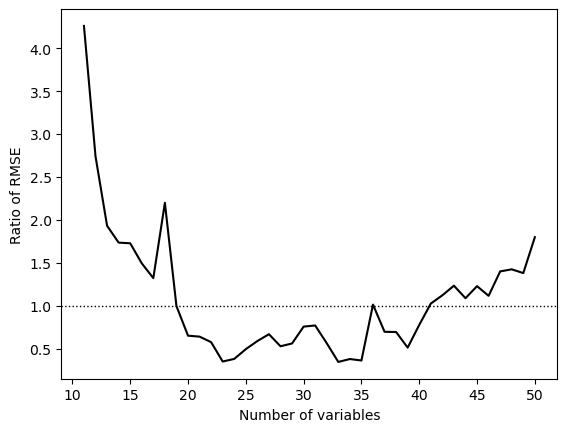

In [306]:
# Best threshold is 1: where models outperform non-selected OLS
threshold = 1
d['ratio'].plot(color='black')
plt.axhline(y=threshold, color='black', linestyle=':', linewidth=1)
plt.ylabel("Ratio of RMSE")
plt.xlabel("Number of variables")
plt.legend().set_visible(False)
plt.show()

We will be interested in Nowcasting using specifications that include the variables selectected by LARS that outperform OLS.

However, for our example, we will use only one of those specifications.

Which one? The one with the best RMSE. We are going to create a list of specifications (spec_list) with all selected specifications. In our case, only one.

In [307]:
spec_list = d[d['rmse']==d['rmse'].min()]
spec_list

,selected_vars,rmse,ratio
size,,,
33,"[FREV1801, RARR2008, RARR3026, GPRI0000, RARR2...",0.107448,0.347966


## Basic Nowcasting

Nowcasting uses a variety of functions. These functions:

- Generate lagged data according to the information set
- Flatten the data into a wide format where additional columns represent periods of the quarter
- Fill missing values with the mean

In [324]:
# Lags is the information sets we calculate
lags = list(range(-2, 3))

# helper function, generate lagged datasets for testing on vintages
def gen_lagged_data(metadata, data, last_date, lag):
    # only go up to the last date
    lagged_data = data.loc[data.date <= last_date, :].reset_index(drop=True)
    for col in lagged_data.columns[1:]:
        pub_lag = metadata.loc[metadata.ticket == col, "months_lag"].values[0] # publication lag of this particular variable
        # go back as far as needed for the pub_lag of the variable, then + the lag (so -2 for 2 months back), also -1 because 0 lag means in month, last month data available, not current month in
        lagged_data.loc[(len(lagged_data) - pub_lag + lag - 1) :, col] = np.nan

    return lagged_data

# helper function, flatten a dataset for methods that don't do timeseries, extra columns for each lag
def flatten_data(data, target_variable, n_lags):
    flattened_data = data.loc[~pd.isna(data[target_variable]), :]
    orig_index = flattened_data.index
    for i in range(1, n_lags + 1):
        lagged_indices = orig_index - i
        lagged_indices = lagged_indices[lagged_indices >= 0]
        tmp = data.loc[lagged_indices, :]
        tmp.date = tmp.date + pd.DateOffset(months=i)
        tmp = tmp.drop([target_variable], axis=1)
        tmp.columns = [j + "_" + str(i) if j != "date" else j for j in tmp.columns]
        flattened_data = flattened_data.merge(tmp, how="left", on="date")

    return flattened_data


def lagged_target(data, total_lags, metadata=metadata, target_variable=target_variable) :
    if total_lags == 0 :
        return data
    else :
        for l in range(1,total_lags+1) :
            data[f"{target_variable}_l{l}"] = data[target_variable]
            data.loc[data.index[-metadata[metadata['ticket']==target_variable]['months_lag'].values[0]:], f"{target_variable}_l{l}"] = np.nan
            data[f"{target_variable}_l{l}"] = data[f"{target_variable}_l{l}"].ffill()
            data[f"{target_variable}_l{l}"] = data[f"{target_variable}_l{l}"].shift(1)
            data[f"{target_variable}_l{l}"] = data[f"{target_variable}_l{l}"].fillna(data[f"{target_variable}_l{l}"].mean())
        return data
    
# helper function fill missings in a dataset with the mean from the training set
def mean_fill_dataset(training, test):
    mean_dict = {}
    for col in training.columns[1:]:
        mean_dict[col] = np.nanmean(training[col])
    filled = test.copy()
    for col in training.columns[1:]:
        filled.loc[pd.isna(filled[col]), col] = mean_dict[col]
        
    return filled


def fit_ols(
    ttrain ,
    gdp_lags = 0,
    flat_lags = 3 ,
    target_variable = target_variable,
    ) :
    transformed_train = flatten_data(ttrain, target_variable, flat_lags )
    # only keep quarterly observations and drop early observations with not enough history for lagged variables
    transformed_train = transformed_train.loc[transformed_train.date.dt.month.astype(int).isin([3,6,9,12]),:].fillna(transformed_train.mean()).dropna(axis=1).reset_index(drop=True)
    transformed_train = lagged_target(transformed_train, gdp_lags)
    
    model = LinearRegression()
    x = transformed_train.drop(["date", target_variable], axis=1)
    y = transformed_train[target_variable]
    return model.fit(x, y) , x.columns


def predict_ols(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l,
    flat_lags = 3 ,
    gdp_lags = 0 ,
    target_variable = target_variable,
    ) :
    # Apply model in test
    Xi = flatten_data(X, target_variable, flat_lags )
    Xi = lagged_target(Xi, gdp_lags)
        
    Xi = Xi.loc[X['date']== date, :].drop(["date", target_variable], axis=1)
    Xi = Xi[train_vars]
    
    pred = model.predict(Xi)[0]
    pred_dict[l].append(pred)
    return pred_dict


def perform_tab( pred_values , model_name , specification , values , lags=lags) :
    # table of RMSE by vintage
    table = pd.DataFrame(columns=[ "Vintage", "RMSE", "estimator", "spec" ])
    for lag in lags:
        tmp = pd.DataFrame({
            "Vintage" : lag,
            "RMSE" : np.sqrt(np.mean((np.array(values) - np.array(pred_values[lag])) ** 2)) ,
            "estimator": model_name ,
            "spec" : specification ,
        }, index=[0])
        table = pd.concat([table, tmp]).reset_index(drop=True)
    table.round(4)
    table.set_index('Vintage' , inplace=True)
    return table

def forecast_table( pred_values , model_name , specification, values  , dates ) :
    # plot of predictions vs actuals
    result = pd.DataFrame(
        {
            "observed": actuals ,
            "two_back": pred_values[-2] ,
            "one_back": pred_values[-1] ,
            "zero_back": pred_values[0] ,
            "one_ahead": pred_values[1] ,
            "two_ahead": pred_values[2] ,
            "estimator": model_name ,
            "spec": specification ,
        }
    )
    result.index = pd.to_datetime(dates)
    return result


We are going to start the Nowcasting exercise with the original (cleaned) dataset in mixed frequencies (Not quarterly)

(The reason is that LARS cannot handle mixed frequencies and flattening. The nowcasting methodology can handle it).

However, limit the variable list to only those selected by LARS + GDP (the target variable)

In [325]:
XVars = spec_list['selected_vars'].values[0]
print(XVars)
print(len(XVars))

['FREV1801', 'RARR2008', 'RARR3026', 'GPRI0000', 'RARR2000', 'RARR3015', 'RARR3022', 'RARR3016', 'RARR0016', 'RARR3013', 'RARR2020', 'RARR1002', 'RARR2019', 'RARR3014', 'RARR0014', 'UGTR0041', 'RARR3025', 'RARR2009', 'RARR2005', 'RARR1034', 'RARR3034', 'UGTR0078', 'RARR2031', 'FREV1003', 'UGTR0011', 'UGTR0081', 'RARR2001', 'RARR3028', 'RARR3017', 'RARR2016', 'RARR3031', 'XEXP0020', 'FDEF0000']
33


In [326]:
df = data[[ col for col in data.columns if col in XVars or col == target_variable ]]
print(f"Data shape: {df.shape}")
df.tail(2)

Data shape: (164, 34)


,FREV1801,FREV1003,FDEF0000,RARR1002,RARR1034,RARR2001,RARR2005,RARR2008,RARR2009,RARR2016,...,RARR0014,RARR0016,RARR2000,RGDP0000,XEXP0020,GPRI0000,UGTR0011,UGTR0041,UGTR0078,UGTR0081
date,,,,,,,,,,,,,,,,,,,,,
2025-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Generate Test dataset**

The test dataset is tricky. It is not a real test dataset. Sorry. Unfortunate name choice.

The test dataset includes all the train data + test data. This was done due to PCA construction.

We will separate it into an actual training and test dataset later.

In [327]:
df = df.reset_index(drop=False)
df.dropna(axis=1, thresh=23, inplace=True)
test = df.loc[(df.date >= train_start_date) & (df.date <= test_end_date), :].reset_index(drop=True)
# DATES AND ACTUAL VALUES
dates = ( pd.date_range(test_start_date, test_end_date, freq="3MS").strftime("%Y-%m-%d").tolist() )
actuals = list(test.loc[test.date.astype(str).isin(dates), target_variable].values)

The list 'dates' includes all (actual) test dates. For each date in the test, we are going to generate a nowcast. The nowcast depends on what month we are located because each month has a different information set.

What that means is that training models are rolling over time, benefitting from additional information that gets published.

In [328]:
dates

['2022-06-01',
 '2022-09-01',
 '2022-12-01',
 '2023-03-01',
 '2023-06-01',
 '2023-09-01',
 '2023-12-01']

The estimation will use 3 PCA factors of selected variables.

The model will be trained depending on the data available at each date.

```transformed_train``` is a dataset that includes the selected variables as factors without missing values.

In [329]:
# param_pca is the number of factors included.
param_pca = 3
spec = " ".join(XVars)

# This empty dictionary will store predicted values.
pred_ols = { k: [] for k in lags }
# This empty table will store RMSE performance
performance_table = pd.DataFrame()
# This empty table will store results
result_table = pd.DataFrame()

for date in dates : 

    # define train dataset
    train = test.loc[test.date <= str(pd.to_datetime(date) - pd.tseries.offsets.DateOffset(months=3))[:10],:]
    transformed_train = mean_fill_dataset(train, train)
    
    # -----------------------------------------------------------------
    # Run PCA scaling
    if param_pca != False or param_pca != 0 :
        if param_pca == True: param_pca=1

        X = pd.DataFrame(scaler.fit_transform(transformed_train.set_index('date').drop(target_variable, axis=1)))
        X.columns = transformed_train.set_index('date').drop(target_variable, axis=1).columns
        X = X.dropna(axis=1)
        pca = PCA(n_components=param_pca)
        
        X = pca.fit_transform(X)
        X = pd.DataFrame(X)
        X.rename(columns=lambda x: f'PC_{x}', inplace=True)
        transformed_train = pd.concat( [ transformed_train[['date', target_variable]] , X ] ,axis=1)

        
        ols_fit, ols_vars = fit_ols( 
            transformed_train , 
            gdp_lags = 2,
            flat_lags = 3
        )

         # -----------------------------------------------------------------
        # Publication Lags in Test data
        for lag in lags:
            # the data available for this date at this artificial vintage
            tmp_data = gen_lagged_data(metadata, test, date, lag)
            # get data in format necessary for model
            tmp_data = mean_fill_dataset(train, tmp_data)
            
            if param_pca != False or param_pca != 0 :                    
                X = pd.DataFrame(scaler.fit_transform(tmp_data.set_index('date').drop(target_variable, axis=1)))
                X.columns = tmp_data.set_index('date').drop(target_variable, axis=1).columns
                X = X.dropna(axis=1)
                pca = PCA(n_components=param_pca)
                
                X = pca.fit_transform(X)
                X = pd.DataFrame(X)
                X.rename(columns=lambda x: f'PC_{x}', inplace=True)
                
                tmp_data = pd.concat( [ tmp_data[['date', target_variable]] , X ] ,axis=1)

            # -----------------------------------------------------------------
            # Predicted values
            pred_ols = predict_ols(
                model=ols_fit,
                X = tmp_data ,
                train_vars = ols_vars,
                date = date,
                l = lag,
                pred_dict = pred_ols ,
                flat_lags = 3 ,
                gdp_lags = 2,
                )
            
performance_table = pd.concat( [ performance_table , perform_tab(pred_ols, "OLS", spec , actuals) ], axis=0)
result_table = pd.concat( [ result_table , forecast_table(pred_ols, "OLS", spec , actuals, dates) ], axis=0)

We observe the results of Nowcasting with OLS in different information windows.

In [330]:
result_table

,observed,two_back,one_back,zero_back,one_ahead,two_ahead,estimator,spec
2022-06-01,1.834934,0.216722,0.580028,0.572464,4.118245,-0.499862,OLS,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...
2022-09-01,1.861167,0.671199,0.388733,0.561130,0.520701,0.366984,OLS,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...
2022-12-01,1.161478,0.727643,0.457876,-0.137346,-0.049291,-0.400583,OLS,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...
2023-03-01,0.365621,0.527314,-0.027953,0.151229,0.109389,-0.390595,OLS,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...
2023-06-01,0.142751,0.669546,-0.309070,-0.264311,-0.316515,-0.795224,OLS,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...
2023-09-01,-0.206811,0.424662,-0.125396,-0.085487,-0.310023,-0.701656,OLS,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...
2023-12-01,0.447653,0.386022,-0.159384,-0.428209,-0.422722,-0.852903,OLS,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...


In [331]:
performance_table

,RMSE,estimator,spec
Vintage,,,
-2,0.839137,OLS,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...
-1,0.842791,OLS,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...
0,0.923068,OLS,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...
1,1.166258,OLS,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...
2,1.389340,OLS,FREV1801 RARR2008 RARR3026 GPRI0000 RARR2000 R...
